In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [12]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [16]:
df.isnull().sum()

,0
Survived,0
Age,0
Fare,0


In [15]:
df.dropna(inplace=True)

In [17]:
df.shape

(714, 3)

In [18]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [21]:
X = df.iloc[:,1:]   # : → all rows
                    # 1: → columns from index 1 to the end   # age and fare

y = df.iloc[:,0]    # : → all rows
                    # 0 → first column

In [22]:

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [23]:
X_train.head(2)

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542


In [24]:

clf = DecisionTreeClassifier()

In [25]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [29]:

accuracy_score(y_test,y_pred)

0.6223776223776224

In [31]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6358763693270735)

In [32]:
kbin_age = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')

In [33]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [34]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [36]:
trf.named_transformers_['first'].n_bins

15

In [37]:
trf.named_transformers_['first'].bin_edges_        # range for age column in quantile

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [38]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [39]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

In [40]:
output['age_labels'] = pd.cut(x=X_train['Age'],
                                    bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['Fare'],
                                    bins=trf.named_transformers_['second'].bin_edges_[0].tolist())



In [43]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
677,18.0,2.0,9.8417,4.0,"(16.0, 19.0]","(8.158, 10.5]"
860,41.0,11.0,14.1083,6.0,"(38.0, 42.0]","(13.0, 14.454]"
218,32.0,9.0,76.2917,13.0,"(30.0, 32.0]","(51.479, 76.292]"
632,32.0,9.0,30.5000,10.0,"(30.0, 32.0]","(26.55, 31.275]"
520,30.0,8.0,93.5000,13.0,"(28.0, 30.0]","(76.292, 108.9]"


In [46]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [47]:
accuracy_score(y_test,y_pred2)

0.6363636363636364

In [55]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6303208137715179)

In [56]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)

    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])

    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()


0.6316901408450704


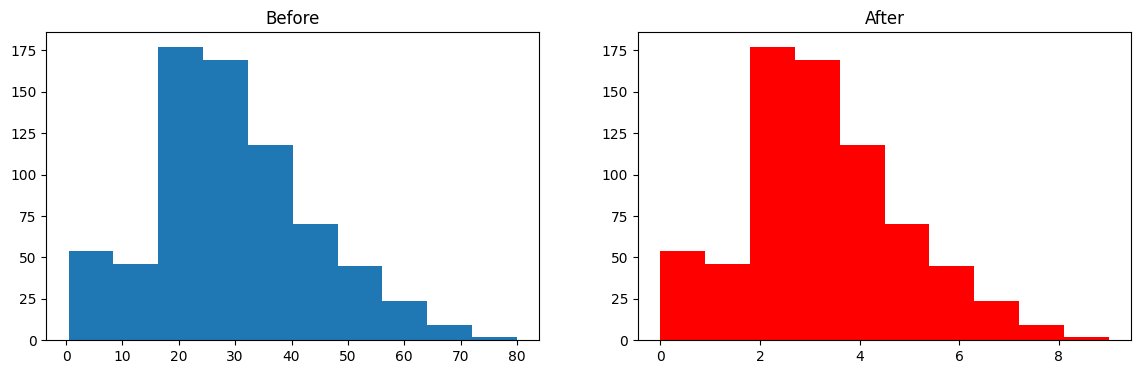

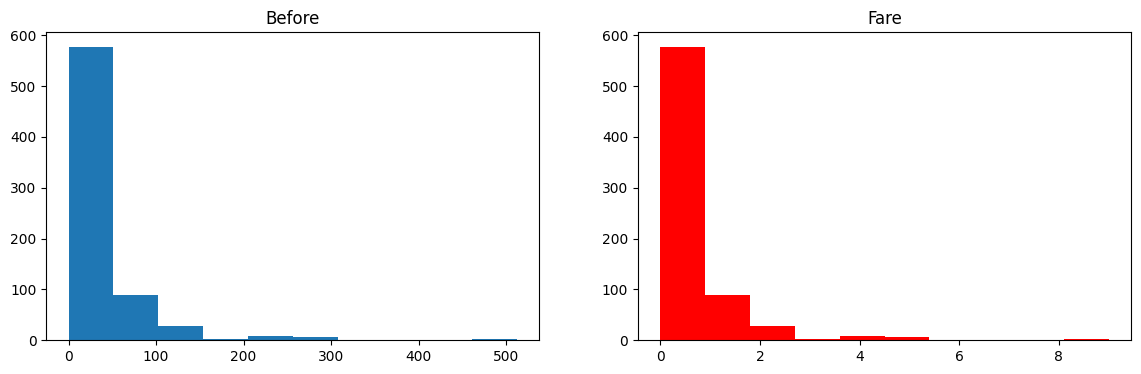

In [57]:
discretize(10,'uniform')

0.6330985915492957


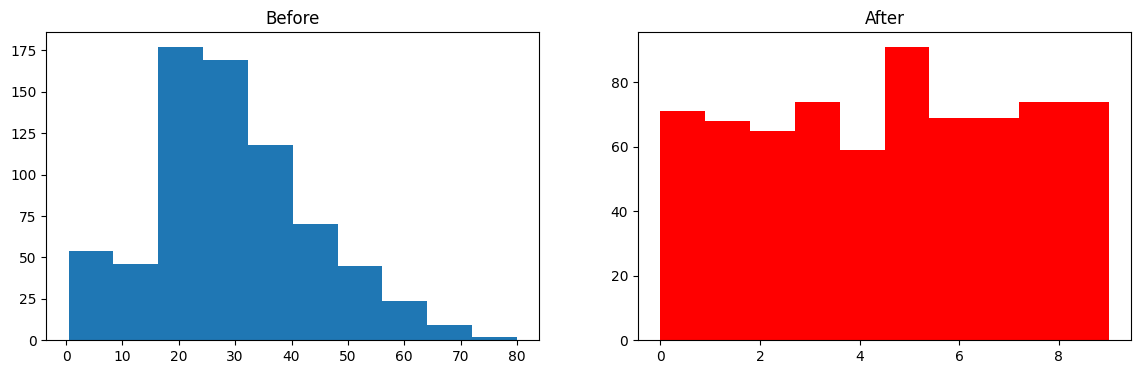

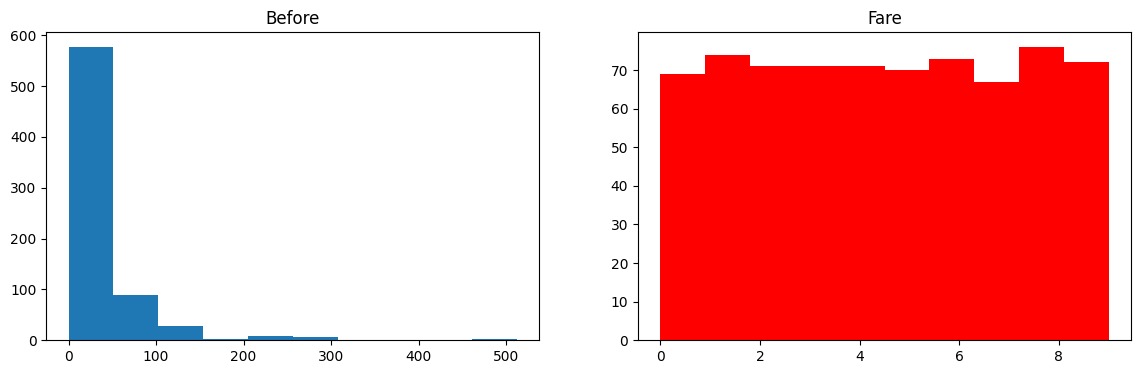

In [58]:
discretize(10,'quantile')

0.6303208137715179


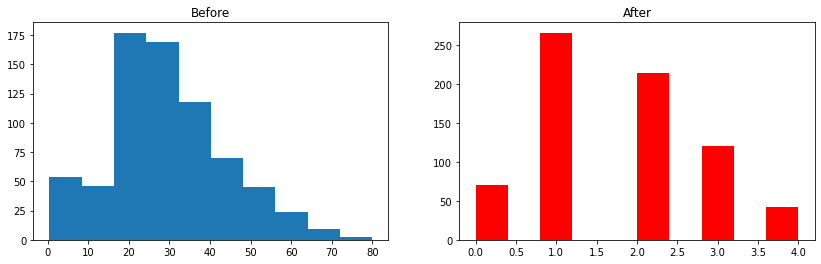

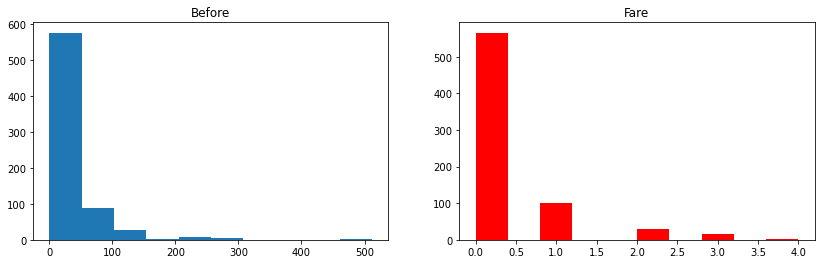

In [ ]:
discretize(5,'kmeans')